# Full Project Notebook: e-SNLI to EBR


# Project Overview

This notebook studies whether human written explanations collected in the LLM era look more similar to LLM generated explanations than to older human explanations.

## Main Research Question

Can a detector trained to separate older human explanations from LLM generated explanations identify a shift toward more LLM like writing in a newer explanation dataset?

## Core Idea

We use an older dataset with human explanations as the baseline for pre LLM explanation style. We then generate synthetic LLM explanations for the same examples and train a classifier to distinguish the two. After that, we apply the classifier to a newer human explanation dataset and examine whether those explanations receive higher LLM likeness scores.

This does **not** prove that annotators definitely used LLMs. Instead, it tests whether newer human explanations show writing patterns that are more consistent with LLM generated text.

## Datasets Used

### Old baseline dataset
**e SNLI**

This dataset contains:
- premise
- hypothesis
- gold label
- human written explanation

We use e SNLI as the source of older human explanations.

### Newer target dataset
**EBR**

This dataset contains:
- question
- answer
- system
- feedback
- additional annotation fields

We use the **feedback** field as the newer human written explanation text.

## What We Are Trying to Show

We want to compare three groups of explanation text:

1. older human explanations from e SNLI  
2. synthetic LLM explanations generated from e SNLI examples  
3. newer human explanations from EBR  

If the EBR explanations receive detector scores that are closer to the synthetic LLM explanations than to the older human explanations, that would be evidence consistent with a shift toward more LLM like explanation style.

## High Level Steps

### Step 1
Load and clean e SNLI.

### Step 2
Sample a balanced subset of e SNLI examples and extract:
- premise
- hypothesis
- label
- one human explanation

### Step 3
Generate one LLM explanation for each sampled e SNLI example using the same input and gold label.

### Step 4
Build a binary classification dataset:
- class 0 is older human explanations
- class 1 is synthetic LLM explanations

### Step 5
Train a main explanation style detector using TF IDF features and Logistic Regression.

### Step 6
Evaluate the detector on held out e SNLI based data.

### Step 7
Train simple control models using shallow style features such as:
- length
- punctuation
- repetition
- stopword ratio
- lexical diversity

### Step 8
Load and clean EBR, using the feedback field as the target explanation text.

### Step 9
Apply the trained detector to:
- older human explanations
- synthetic LLM explanations
- newer human explanations from EBR

### Step 10
Compare score distributions across the three groups.

### Step 11
Run control analyses such as:
- length matched comparisons
- style only detector comparisons

### Step 12
Perform a qualitative audit of high scoring and low scoring EBR explanations.

## Expected Outcome

By the end of this notebook, we should have:

- a trained detector that distinguishes older human explanations from synthetic LLM explanations
- score distributions for older human, synthetic LLM, and newer human explanations
- plots and summary statistics showing whether the newer explanations shift toward LLM like writing
- a short qualitative analysis of the explanations that appear most and least LLM like

## Important Interpretation Note

The results from this notebook should be interpreted carefully. A higher LLM likeness score for newer explanations does **not** prove direct LLM use by annotators. It only shows that the newer explanations share more surface or stylistic properties with LLM generated text than the older baseline explanations do.

### Environment And Imports
This cell initializes the notebook environment and imports all core libraries required for dataset processing, modeling, controls, visualization, and export.

Step-by-step:
1. Load foundational Python utilities.
2. Load data-science and ML packages.
3. Prepare tools used throughout the full pipeline.


In [ ]:


from __future__ import annotations

import json
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm



### Load e-SNLI Source Dataset
This cell downloads/loads e-SNLI from Hugging Face as the historical human-explanation baseline.

Step-by-step:
1. Connect to the dataset source.
2. Materialize dataset splits for downstream processing.
3. Hand off to train/test inspection in the next cell.


In [ ]:


dataset = load_dataset("esnli",trust_remote_code=True)


### Inspect e-SNLI Train/Test Splits
This cell converts e-SNLI splits into pandas DataFrames and provides a quick inspection of dataset size and content.

Step-by-step:
1. Convert train and test splits into tabular format.
2. Print row counts for sanity checking.
3. Preview sample rows to validate schema.



In [28]:


train = pd.DataFrame(dataset["train"])
test = pd.DataFrame(dataset["test"])

print(f"train rows: {len(train)}")
print(f"test rows: {len(test)}")

test.head()


train rows: 549367
test rows: 9824


,premise,hypothesis,label,explanation_1,explanation_2,explanation_3
0,This church choir sings to the masses as they ...,The church has cracks in the ceiling.,1,Not all churches have cracks in the ceiling,There is no indication that there are cracks i...,Not all churches have cracks in the ceiling.
1,This church choir sings to the masses as they ...,The church is filled with song.,0,"""Filled with song"" is a rephrasing of the ""cho...",hearing song brings joyous in the church.,If the church choir sings then the church is f...
2,This church choir sings to the masses as they ...,A choir singing at a baseball game.,2,A choir sing some other songs other than book ...,The choir is at a chruch not a baseball game.,A baseball game isn’t played at a church.
3,"A woman with a green headscarf, blue shirt and...",The woman is young.,1,the woman could've been old rather than young,There is no indication that the woman is young.,Not all women are young.
4,"A woman with a green headscarf, blue shirt and...",The woman is very happy.,0,a grin suggests hapiness.,A WOMAN WITH BIG GRIN IS HAPPY,One must be happy in order to have a big grin.


### Build Balanced e-SNLI Subsets
This cell creates balanced train/test subsets of e-SNLI and saves them to raw data for reproducible downstream modeling.

Step-by-step:
1. Define balanced sampling by NLI label.
2. Build cleaned train/test explanation subsets.
3. Save subset CSV files for old-human baseline data.



In [ ]:
def _balanced_sample_by_label(df: pd.DataFrame, label_col: str, n: int, seed: int) -> pd.DataFrame:
    labels = sorted(df[label_col].dropna().astype(int).unique().tolist())
    if not labels or len(df) <= n:
        return df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    per_label = n // len(labels)
    remainder = n % len(labels)
    parts = []
    used_indices = set()

    for i, lbl in enumerate(labels):
        cur = df[df[label_col].astype(int) == lbl]
        take = min(len(cur), per_label + (1 if i < remainder else 0))
        if take > 0:
            sampled = cur.sample(n=take, random_state=seed + i)
            parts.append(sampled)
            used_indices.update(sampled.index.tolist())

    out = pd.concat(parts, ignore_index=False) if parts else df.iloc[:0].copy()

    if len(out) < n:
        remaining = df.drop(index=list(used_indices), errors='ignore')
        if len(remaining) > 0:
            add_n = min(n - len(out), len(remaining))
            add = remaining.sample(n=add_n, random_state=seed + 999)
            out = pd.concat([out, add], ignore_index=False)

    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


subset_size = 8000
project_root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
raw_dir = project_root / 'data' / 'raw'
raw_dir.mkdir(parents=True, exist_ok=True)

train_out_path = raw_dir / 'esnli_subset.csv'          
test_out_path = raw_dir / 'esnli_test_subset.csv'
FORCE_REBUILD_SUBSETS = False

if train_out_path.exists() and test_out_path.exists() and not FORCE_REBUILD_SUBSETS:
    print('Existing e-SNLI subset files found. Skipping rebuild to preserve alignment with LLM CSV files.')
    print(f'Using: {train_out_path}')
    print(f'Using: {test_out_path}')
else:
    exp_col_train = 'explanation_1' if 'explanation_1' in train.columns else 'explanation'
    exp_col_test = 'explanation_1' if 'explanation_1' in test.columns else 'explanation'

    train_clean = (
        train[['premise', 'hypothesis', 'label', exp_col_train]]
        .rename(columns={exp_col_train: 'explanation'})
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )
    train_clean['label'] = train_clean['label'].astype(int)

    test_clean = (
        test[['premise', 'hypothesis', 'label', exp_col_test]]
        .rename(columns={exp_col_test: 'explanation'})
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )
    test_clean['label'] = test_clean['label'].astype(int)

    train_subset = _balanced_sample_by_label(train_clean, 'label', min(subset_size, len(train_clean)), seed=42)
    test_subset = _balanced_sample_by_label(test_clean, 'label', min(subset_size, len(test_clean)), seed=42)

    train_subset.to_csv(train_out_path, index=False)
    test_subset.to_csv(test_out_path, index=False)

    print(f'Saved balanced train subset: {len(train_subset)} rows -> {train_out_path}')
    print(train_subset['label'].value_counts().sort_index().to_dict())
    print(f'Saved balanced test subset: {len(test_subset)} rows -> {test_out_path}')
    print(test_subset['label'].value_counts().sort_index().to_dict())

pd.read_csv(train_out_path).head()


Existing e-SNLI subset files found. Skipping rebuild to preserve alignment with LLM CSV files.
Using: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_subset.csv
Using: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_test_subset.csv


,premise,hypothesis,label,explanation
0,Two people standing next to a road looking off...,Two people are outside.,0,people standing next to a road looking off a h...
1,People up form their seats with two TVs hangin...,There are people watching TV,0,: People implies are people
2,A young boy climbing a tree in grassy hills.,A boy climbing a tree.,0,The boy is climbing a tree so he must be young.
3,A man in a black hat walks down the street.,The man is walking home.,1,We cannot know the destination to which the ma...
4,Five women in purple outfits wait outside.,the women are models,1,"anybody can wear an outfit, not just models"


### Load And Cache EBR Dataset
This cell loads EBR train/test splits and saves raw CSV files so the newer human-feedback target data is locally available.

Step-by-step:
1. Load EBR train and test splits.
2. Inspect shapes and available fields.
3. Save train/test and combined EBR feedback CSV files.



In [30]:


out_dir = Path("../data/raw")
out_dir.mkdir(parents=True, exist_ok=True)

train_df = load_dataset("wadhma/EBR", split="train").to_pandas()
test_df  = load_dataset("wadhma/EBR", split="test").to_pandas()

print(train_df.shape, test_df.shape)
print(train_df.columns.tolist())

train_df.to_csv(out_dir / "ebr_train.csv", index=False)
test_df.to_csv(out_dir / "ebr_test.csv", index=False)

ebr_feedback = pd.concat(
    [train_df.assign(split="train"), test_df.assign(split="test")],
    ignore_index=True
)
ebr_feedback.to_csv(out_dir / "ebr_feedback.csv", index=False)

print("Saved:", out_dir / "ebr_train.csv")
print("Saved:", out_dir / "ebr_test.csv")
print("Saved:", out_dir / "ebr_feedback.csv")

(7058, 13) (5592, 13)
['articleid', 'dataset', 'questionid', 'question', 'system', 'answer', 'annotationid', 'correct_label', 'complete_label', 'feedback', 'ebr_raw', 'ebr_num', 'workerid']
Saved: ../data/raw/ebr_train.csv
Saved: ../data/raw/ebr_test.csv
Saved: ../data/raw/ebr_feedback.csv


### Define Project Configuration And Utility Features
This cell centralizes project paths and experiment settings, then defines reusable text-style feature helpers.

Step-by-step:
1. Set directories and experiment constants.
2. Define tokenization and shallow style-feature utilities.
3. Prepare common helpers used by training and controls.



In [ ]:
@dataclass
class Config:
    project_root: Path = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
    data_raw_dir: Path = project_root / 'data' / 'raw'
    data_processed_dir: Path = project_root / 'data' / 'processed'
    outputs_dir: Path = project_root / 'outputs'
    models_dir: Path = outputs_dir / 'models'
    figures_dir: Path = outputs_dir / 'figures'
    reports_dir: Path = outputs_dir / 'reports'

    esnli_subset_size: int = 8000
    esnli_subset_csv: Path = data_raw_dir / 'esnli_subset.csv'
    esnli_test_subset_csv: Path = data_raw_dir / 'esnli_test_subset.csv'

    # Pre-generated synthetic e-SNLI explanations 
    esnli_llm_csv: Path = data_raw_dir / 'esnli_llm_explanations.csv'
    esnli_llm_train_csv: Path = data_raw_dir / 'esnli_llm_explanations_train.csv'
    esnli_llm_test_csv: Path = data_raw_dir / 'esnli_llm_explanations_test.csv'

    # EBR (LLM-era target)
    ebr_dataset_name: str = 'EBR'
    ebr_target_csv: Path = data_raw_dir / 'ebr_feedback.csv'  

    random_seed: int = 42
    test_size: float = 0.2

    tfidf_max_features: int = 30000
    llm_like_threshold: float = 0.8
    length_q_low: float = 0.1
    length_q_high: float = 0.9

CFG = Config()

for p in [
    CFG.data_raw_dir,
    CFG.data_processed_dir,
    CFG.outputs_dir,
    CFG.models_dir,
    CFG.figures_dir,
    CFG.reports_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}

_WORD_RE = re.compile(r'\b\w+\b')
STOPWORDS = {
    'a','an','and','are','as','at','be','by','for','from','has','he','in','is','it','its','of','on',
    'that','the','to','was','were','will','with','this','these','those','their','there','because',
    'but','or','if','then','than'
}


def _pick_first_existing(columns: list[str], candidates: list[str]) -> Optional[str]:
    cols = set(columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def _tokenize(text: str) -> list[str]:
    return _WORD_RE.findall(str(text).lower())


def token_count(text: str) -> int:
    return len(_tokenize(text))


def style_feature_df(texts: pd.Series) -> pd.DataFrame:
    rows = []
    for txt in texts.astype(str).fillna(''):
        toks = _tokenize(txt)
        n = len(toks)
        uniq = len(set(toks))
        stop = sum(1 for t in toks if t in STOPWORDS)
        rows.append({
            'token_count': n,
            'char_count': len(txt),
            'punct_count': sum(ch in '.,!?:;' for ch in txt),
            'repeat_rate': 0.0 if n == 0 else 1.0 - (uniq / n),
            'stopword_ratio': 0.0 if n == 0 else stop / n,
            'lexical_diversity': 0.0 if n == 0 else uniq / n,
        })
    return pd.DataFrame(rows)


def length_filter(df: pd.DataFrame, col: str, q_low: float, q_high: float) -> pd.DataFrame:
    lengths = df[col].astype(str).map(token_count)
    lo = np.quantile(lengths, q_low)
    hi = np.quantile(lengths, q_high)
    return df[(lengths >= lo) & (lengths <= hi)].copy()



### Data Loaders For e-SNLI And EBR
This cell defines robust loaders to standardize e-SNLI subsets and EBR feedback into a unified explanation-text format.

Step-by-step:
1. Normalize e-SNLI labels and columns.
2. Load balanced old-human subsets.
3. Normalize EBR feedback and metadata fields for target scoring.



In [32]:
def _normalize_label_value(v):
    if pd.isna(v):
        return np.nan

    s = str(v).strip().lower()
    if s in LABEL_MAP.values():
        inv = {name: idx for idx, name in LABEL_MAP.items()}
        return inv[s]

    try:
        return int(float(s))
    except Exception:
        return np.nan


def _balanced_sample_by_label_local(df: pd.DataFrame, label_col: str, n: int, seed: int) -> pd.DataFrame:
    labels = sorted(df[label_col].dropna().astype(int).unique().tolist())
    if not labels or len(df) <= n:
        return df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    per_label = n // len(labels)
    remainder = n % len(labels)
    parts = []
    used_indices = set()

    for i, lbl in enumerate(labels):
        cur = df[df[label_col].astype(int) == lbl]
        take = min(len(cur), per_label + (1 if i < remainder else 0))
        if take > 0:
            sampled = cur.sample(n=take, random_state=seed + i)
            parts.append(sampled)
            used_indices.update(sampled.index.tolist())

    out = pd.concat(parts, ignore_index=False) if parts else df.iloc[:0].copy()

    if len(out) < n:
        remaining = df.drop(index=list(used_indices), errors='ignore')
        if len(remaining) > 0:
            add_n = min(n - len(out), len(remaining))
            add = remaining.sample(n=add_n, random_state=seed + 999)
            out = pd.concat([out, add], ignore_index=False)

    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def load_esnli_subset(
    n: int,
    seed: int,
    subset_csv: Optional[Path] = None,
    train_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    if subset_csv is not None and Path(subset_csv).exists():
        df = pd.read_csv(subset_csv)
        source = f'CSV ({subset_csv})'
    elif train_df is not None and not train_df.empty:
        df = train_df.copy()
        source = 'existing `train` DataFrame in notebook memory'
    else:
        ds = load_dataset('esnli')
        df = ds['train'].to_pandas()
        source = 'Hugging Face e-SNLI train split'

    cols = df.columns.tolist()
    premise_col = _pick_first_existing(cols, ['premise', 'sentence1', 'premise_text'])
    hypo_col = _pick_first_existing(cols, ['hypothesis', 'sentence2', 'hypothesis_text'])
    label_col = _pick_first_existing(cols, ['label', 'gold_label', 'nli_label'])
    exp_col = _pick_first_existing(cols, ['explanation_1', 'explanation', 'sentence_explanation'])

    missing = []
    if premise_col is None:
        missing.append('premise')
    if hypo_col is None:
        missing.append('hypothesis')
    if label_col is None:
        missing.append('label')
    if exp_col is None:
        missing.append('explanation')
    if missing:
        raise ValueError(f'Missing required e-SNLI columns in {source}: {missing}. Found: {cols}')

    out = (
        df[[premise_col, hypo_col, label_col, exp_col]]
        .rename(columns={
            premise_col: 'premise',
            hypo_col: 'hypothesis',
            label_col: 'label',
            exp_col: 'explanation',
        })
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )

    out['label'] = out['label'].map(_normalize_label_value)
    out = out.dropna(subset=['label']).copy()
    out['label'] = out['label'].astype(int)

    if len(out) > n:
        out = _balanced_sample_by_label_local(out, 'label', n=n, seed=seed)

    out = out.reset_index(drop=True)
    out['label_name'] = out['label'].map(lambda x: LABEL_MAP.get(int(x), str(x)))
    return out


def _normalize_ebr_frame(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    cols = [c.lower() for c in df.columns]
    cmap = {c.lower(): c for c in df.columns}

    feedback_col = _pick_first_existing(cols, ['feedback', 'explanation', 'rationale', 'justification'])
    if feedback_col is None:
        raise ValueError(f'Could not find feedback/explanation column in EBR split={split_name}. Found: {list(df.columns)}')

    question_col = _pick_first_existing(cols, ['question', 'prompt'])
    answer_col = _pick_first_existing(cols, ['answer', 'response'])
    system_col = _pick_first_existing(cols, ['system', 'model', 'model_name'])
    correct_label_col = _pick_first_existing(cols, ['correct_label'])
    complete_label_col = _pick_first_existing(cols, ['complete_label'])
    ebr_num_col = _pick_first_existing(cols, ['ebr_num', 'score'])

    out = pd.DataFrame({'explanation': df[cmap[feedback_col]].astype(str)})
    if question_col:
        out['question'] = df[cmap[question_col]].astype(str)
    if answer_col:
        out['answer'] = df[cmap[answer_col]].astype(str)
    if system_col:
        out['system'] = df[cmap[system_col]].astype(str)
    if correct_label_col:
        out['correct_label'] = df[cmap[correct_label_col]]
    if complete_label_col:
        out['complete_label'] = df[cmap[complete_label_col]]
    if ebr_num_col:
        out['ebr_num'] = df[cmap[ebr_num_col]]

    out['split'] = split_name
    out = out.dropna(subset=['explanation'])
    out['explanation'] = out['explanation'].astype(str).str.strip()
    out = out[out['explanation'].str.len() > 0].reset_index(drop=True)
    return out


def load_ebr_human_feedback(dataset_name: str = 'wadhma/EBR', local_csv: Optional[Path] = None) -> pd.DataFrame:
    if local_csv is not None and Path(local_csv).exists():
        df = pd.read_csv(local_csv)
        out = _normalize_ebr_frame(df, split_name='local_csv')
        out['source'] = f'local_csv:{local_csv}'
        return out

    ds = load_dataset(dataset_name)
    frames = []
    for split_name in ['train', 'test', 'validation']:
        if split_name in ds:
            cur = ds[split_name].to_pandas()
            cur = _normalize_ebr_frame(cur, split_name=split_name)
            frames.append(cur)

    if not frames:
        raise ValueError(f'No usable splits found in dataset: {dataset_name}')

    out = pd.concat(frames, ignore_index=True)
    out['source'] = f'hf_dataset:{dataset_name}'
    return out



### Load Synthetic Old-LLM Explanations
This cell aligns pre-generated e-SNLI LLM explanation CSVs with old-human subsets for detector training.

Step-by-step:
1. Read synthetic LLM explanation files.
2. Align by premise/hypothesis when possible.
3. Apply safe row-order fallback only when needed.



### Synthetic LLM Explanations Provenance
The synthetic e-SNLI LLM explanations used in this project were generated with an OpenAI LLM in a prior step and saved to CSV files (`esnli_llm_explanations_train.csv`, `esnli_llm_explanations_test.csv`, and `esnli_llm_explanations.csv`).


In [33]:
def load_llm_explanations_from_csv(
    old_human: pd.DataFrame,
    csv_path: Path,
    allow_row_fallback: bool = True,
    min_match_ratio: float = 0.95,
) -> pd.DataFrame:
    if not Path(csv_path).exists():
        raise FileNotFoundError(f'Missing {csv_path}.')

    df = pd.read_csv(csv_path)
    cols = df.columns.tolist()
    exp_col = _pick_first_existing(cols, ['explanation', 'llm_explanation', 'generated_explanation'])
    if exp_col is None:
        raise ValueError(f'Could not find explanation column in {csv_path}. Found: {cols}')

    premise_col = _pick_first_existing(cols, ['premise', 'sentence1', 'premise_text'])
    hypo_col = _pick_first_existing(cols, ['hypothesis', 'sentence2', 'hypothesis_text'])

    base = old_human[['premise', 'hypothesis', 'label', 'label_name']].copy().reset_index(drop=True)

    # Preferred path: exact premise/hypothesis alignment.
    if premise_col and hypo_col:
        temp = (
            df[[premise_col, hypo_col, exp_col]]
            .rename(columns={premise_col: 'premise', hypo_col: 'hypothesis', exp_col: 'explanation'})
            .dropna(subset=['premise', 'hypothesis', 'explanation'])
        )
        temp = temp.drop_duplicates(subset=['premise', 'hypothesis'], keep='first')
        merged = base.merge(temp, on=['premise', 'hypothesis'], how='left')
        missing = int(merged['explanation'].isna().sum())
        match_ratio = 1.0 - (missing / max(len(base), 1))

        if missing == 0:
            return merged

        # Fallback: row-order alignment if we likely have same-size paired files but changed subset sampling.
        if allow_row_fallback:
            temp_row = df[[exp_col]].rename(columns={exp_col: 'explanation'}).dropna(subset=['explanation']).reset_index(drop=True)
            if len(temp_row) >= len(base):
                out = base.copy()
                out['explanation'] = temp_row['explanation'].astype(str).iloc[:len(base)].values
                print(
                    f'Warning: premise/hypothesis match ratio={match_ratio:.2%} (<{min_match_ratio:.0%}). '
                    'Using row-order fallback for LLM explanations. '
                    'If this is unintended, regenerate LLM explanations from the current subset.'
                )
                return out

        raise ValueError(
            f'{missing} rows from e-SNLI subset do not have matching explanations in {csv_path}. '
            'Provide premise+hypothesis columns for exact matching or one explanation per row in subset order.'
        )

    # Row-order alignment path.
    temp = df[[exp_col]].rename(columns={exp_col: 'explanation'}).dropna(subset=['explanation']).reset_index(drop=True)
    if len(temp) < len(base):
        raise ValueError(
            f'Explanation row count mismatch for {csv_path}: got {len(temp)}, expected at least {len(base)}. '
            'Provide premise+hypothesis columns for merging, or provide one explanation per subset row.'
        )

    out = base.copy()
    out['explanation'] = temp['explanation'].astype(str).iloc[:len(base)].values
    return out



### Train Main Detector And Control Models
This cell defines all modeling functions: main TF-IDF detector, style-only control, length-matched control, scoring, summaries, and qualitative pattern extraction.

Step-by-step:
1. Train/evaluate the main explanation-style detector.
2. Train/evaluate style-only and length-matched controls.
3. Score groups, summarize distributions, and prepare audit/pattern tools.



In [34]:
def train_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    train_df = pd.concat([
        old_human_train[['explanation']].assign(y=0),
        old_llm_train[['explanation']].assign(y=1),
    ], ignore_index=True)

    vectorizer = TfidfVectorizer(max_features=CFG.tfidf_max_features, ngram_range=(1, 2), lowercase=True)
    Xtr = vectorizer.fit_transform(train_df['explanation'].astype(str))
    ytr = train_df['y'].values

    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, ytr)

    if old_human_eval is not None and old_llm_eval is not None:
        eval_df = pd.concat([
            old_human_eval[['explanation']].assign(y=0),
            old_llm_eval[['explanation']].assign(y=1),
        ], ignore_index=True)
        Xte = vectorizer.transform(eval_df['explanation'].astype(str))
        yte = eval_df['y'].values
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            train_df['explanation'].astype(str),
            train_df['y'],
            test_size=CFG.test_size,
            random_state=CFG.random_seed,
            stratify=train_df['y'],
        )
        vectorizer = TfidfVectorizer(max_features=CFG.tfidf_max_features, ngram_range=(1, 2), lowercase=True)
        Xtr = vectorizer.fit_transform(X_train)
        Xte = vectorizer.transform(X_test)
        clf = LogisticRegression(max_iter=2000)
        clf.fit(Xtr, y_train)
        yte = y_test.values

    p_test = clf.predict_proba(Xte)[:, 1]
    y_pred = (p_test >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(yte, y_pred)),
        'auroc': float(roc_auc_score(yte, p_test)),
    }
    return vectorizer, clf, metrics


def train_style_only_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    train_df = pd.concat([
        old_human_train[['explanation']].assign(y=0),
        old_llm_train[['explanation']].assign(y=1),
    ], ignore_index=True)

    Xs_train = style_feature_df(train_df['explanation'])
    ys_train = train_df['y'].values
    style_clf = LogisticRegression(max_iter=2000)
    style_clf.fit(Xs_train, ys_train)

    if old_human_eval is not None and old_llm_eval is not None:
        eval_df = pd.concat([
            old_human_eval[['explanation']].assign(y=0),
            old_llm_eval[['explanation']].assign(y=1),
        ], ignore_index=True)
        Xs_test = style_feature_df(eval_df['explanation'])
        ys_test = eval_df['y'].values
    else:
        Xs_train_split, Xs_test, ys_train_split, ys_test = train_test_split(
            Xs_train, ys_train,
            test_size=CFG.test_size,
            random_state=CFG.random_seed,
            stratify=ys_train,
        )
        style_clf = LogisticRegression(max_iter=2000)
        style_clf.fit(Xs_train_split, ys_train_split)

    ps = style_clf.predict_proba(Xs_test)[:, 1]
    yhs = (ps >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(ys_test, yhs)),
        'auroc': float(roc_auc_score(ys_test, ps)),
    }
    return style_clf, metrics


def _compute_length_band(train_texts: pd.Series, q_low: float, q_high: float) -> tuple[float, float]:
    lengths = train_texts.astype(str).map(token_count)
    lo = float(np.quantile(lengths, q_low))
    hi = float(np.quantile(lengths, q_high))
    return lo, hi


def _filter_by_band(df: pd.DataFrame, lo: float, hi: float) -> pd.DataFrame:
    lengths = df['explanation'].astype(str).map(token_count)
    return df[(lengths >= lo) & (lengths <= hi)].copy()


def train_length_matched_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    train_df = pd.concat([
        old_human_train[['explanation']].assign(y=0),
        old_llm_train[['explanation']].assign(y=1),
    ], ignore_index=True)

    lo, hi = _compute_length_band(train_df['explanation'], CFG.length_q_low, CFG.length_q_high)
    train_len = _filter_by_band(train_df, lo, hi)

    vec = TfidfVectorizer(max_features=CFG.tfidf_max_features, ngram_range=(1, 2), lowercase=True)
    Xtr = vec.fit_transform(train_len['explanation'].astype(str))
    ytr = train_len['y'].values
    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, ytr)

    if old_human_eval is not None and old_llm_eval is not None:
        eval_df = pd.concat([
            old_human_eval[['explanation']].assign(y=0),
            old_llm_eval[['explanation']].assign(y=1),
        ], ignore_index=True)
        eval_len = _filter_by_band(eval_df, lo, hi)
        Xte = vec.transform(eval_len['explanation'].astype(str))
        yte = eval_len['y'].values
        n_eval = int(len(eval_len))
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            train_len['explanation'].astype(str),
            train_len['y'],
            test_size=CFG.test_size,
            random_state=CFG.random_seed,
            stratify=train_len['y'],
        )
        vec = TfidfVectorizer(max_features=CFG.tfidf_max_features, ngram_range=(1, 2), lowercase=True)
        Xtr = vec.fit_transform(X_train)
        Xte = vec.transform(X_test)
        clf = LogisticRegression(max_iter=2000)
        clf.fit(Xtr, y_train)
        yte = y_test.values
        n_eval = int(len(yte))

    p = clf.predict_proba(Xte)[:, 1]
    yhat = (p >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(yte, yhat)),
        'auroc': float(roc_auc_score(yte, p)),
        'n_train_len': int(len(train_len)),
        'n_eval_len': n_eval,
        'length_lo': lo,
        'length_hi': hi,
    }
    return vec, clf, metrics, (lo, hi)


def score_groups_main(vectorizer, clf, old_human_eval: pd.DataFrame, old_llm_eval: pd.DataFrame, ebr_human: pd.DataFrame) -> pd.DataFrame:
    groups = [
        old_human_eval[['explanation']].assign(group='old_human'),
        old_llm_eval[['explanation']].assign(group='old_llm'),
        ebr_human[['explanation']].assign(group='new_human'),
    ]
    scored = []
    for g in groups:
        X = vectorizer.transform(g['explanation'].astype(str))
        p = clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        scored.append(cur)
    return pd.concat(scored, ignore_index=True)


def score_groups_style(style_clf, old_human_eval: pd.DataFrame, old_llm_eval: pd.DataFrame, ebr_human: pd.DataFrame) -> pd.DataFrame:
    groups = [
        old_human_eval[['explanation']].assign(group='old_human'),
        old_llm_eval[['explanation']].assign(group='old_llm'),
        ebr_human[['explanation']].assign(group='new_human'),
    ]
    scored = []
    for g in groups:
        X = style_feature_df(g['explanation'])
        p = style_clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        scored.append(cur)
    return pd.concat(scored, ignore_index=True)


def score_groups_length_matched(vectorizer, clf, old_human_eval: pd.DataFrame, old_llm_eval: pd.DataFrame, ebr_human: pd.DataFrame, lo: float, hi: float) -> pd.DataFrame:
    groups = [
        _filter_by_band(old_human_eval[['explanation']].assign(group='old_human'), lo, hi),
        _filter_by_band(old_llm_eval[['explanation']].assign(group='old_llm'), lo, hi),
        _filter_by_band(ebr_human[['explanation']].assign(group='new_human'), lo, hi),
    ]
    scored = []
    for g in groups:
        X = vectorizer.transform(g['explanation'].astype(str))
        p = clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        cur['token_count'] = cur['explanation'].astype(str).map(token_count)
        scored.append(cur)
    return pd.concat(scored, ignore_index=True)


def summarize_scores(scored: pd.DataFrame, threshold: float = None) -> pd.DataFrame:
    th = CFG.llm_like_threshold if threshold is None else threshold
    return (
        scored.groupby('group')['llm_likeness']
        .agg(
            mean='mean',
            median='median',
            pct_above_threshold=lambda s: (s >= th).mean() * 100,
            n='count',
        )
        .reset_index()
    )


def qualitative_audit(scored: pd.DataFrame, n_each: int = 20) -> pd.DataFrame:
    target = scored[scored['group'] == 'new_human'].copy()
    high = target.nlargest(n_each, 'llm_likeness').assign(bucket='high_score')
    low = target.nsmallest(n_each, 'llm_likeness').assign(bucket='low_score')
    return pd.concat([high, low], ignore_index=True)


def summarize_audit_patterns(audit_df: pd.DataFrame, top_k: int = 20) -> str:
    if audit_df.empty:
        return 'No audit rows available.'

    out = []
    for bucket in ['high_score', 'low_score']:
        cur = audit_df[audit_df['bucket'] == bucket].copy()
        if cur.empty:
            continue
        texts = cur['explanation'].astype(str)
        feats = style_feature_df(texts)
        out.append(f'### {bucket}')
        out.append(f'- n: {len(cur)}')
        out.append(f"- mean_token_count: {feats['token_count'].mean():.2f}")
        out.append(f"- mean_punct_count: {feats['punct_count'].mean():.2f}")
        out.append(f"- mean_repeat_rate: {feats['repeat_rate'].mean():.4f}")
        out.append(f"- mean_stopword_ratio: {feats['stopword_ratio'].mean():.4f}")
        out.append(f"- mean_lexical_diversity: {feats['lexical_diversity'].mean():.4f}")

        tokens = []
        for txt in texts:
            toks = [t for t in _tokenize(txt) if t not in STOPWORDS and len(t) > 2]
            tokens.extend(toks)
        common = [w for w, _ in Counter(tokens).most_common(top_k)]
        out.append(f"- top_tokens: {', '.join(common)}")
        out.append('')

    out.append('### Interpretation Notes')
    out.append('- High-scoring EBR feedback tends to align with model-like style markers when token count and repeated phrasing increase and lexical diversity drops.')
    out.append('- Low-scoring EBR feedback tends to look more human-like when explanations are shorter, more specific, and less template-like.')
    return '\n'.join(out)


def plot_distributions(scored: pd.DataFrame, output_png: Path, title: str) -> None:
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.histplot(
        data=scored,
        x='llm_likeness',
        hue='group',
        bins=30,
        stat='density',
        common_norm=False,
        alpha=0.4,
        ax=axes[0],
    )
    axes[0].set_title(title)
    axes[0].set_xlim(0, 1)

    sns.boxplot(data=scored, x='group', y='llm_likeness', ax=axes[1])
    axes[1].set_title('Group score comparison')
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    fig.savefig(output_png, dpi=180)
    plt.close(fig)



### Run Full End-To-End Pipeline
This cell executes the complete workflow from data loading through model training, scoring, controls, visualization, qualitative audit, and artifact export.

Step-by-step:
1. Load old-human and old-LLM train/eval sets.
2. Load and inspect EBR target feedback.
3. Train models, score all groups, run controls, and save outputs.



In [35]:
# --------------------
# Run entire pipeline
# --------------------

ESNLI_TRAIN_CSV = CFG.esnli_subset_csv
ESNLI_TEST_CSV = CFG.esnli_test_subset_csv
ESNLI_TRAIN_DF = train if ('train' in globals() and isinstance(train, pd.DataFrame)) else None

# Use pre-generated synthetic explanations.
LLM_TRAIN_CSV = CFG.esnli_llm_train_csv if CFG.esnli_llm_train_csv.exists() else CFG.esnli_llm_csv
LLM_TEST_CSV = CFG.esnli_llm_test_csv if CFG.esnli_llm_test_csv.exists() else None

human_train_cache = CFG.data_processed_dir / 'esnli_old_human_train.csv'
human_test_cache = CFG.data_processed_dir / 'esnli_old_human_test.csv'
llm_train_cache = CFG.data_processed_dir / 'esnli_old_llm_train.csv'
llm_test_cache = CFG.data_processed_dir / 'esnli_old_llm_test.csv'
ebr_cache = CFG.data_processed_dir / 'ebr_new_human.csv'

# 1) Load and inspect e-SNLI baseline + balanced subsets
if ESNLI_TRAIN_CSV.exists():
    old_human_train = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, subset_csv=ESNLI_TRAIN_CSV)
    old_human_train.to_csv(human_train_cache, index=False)
    print(f'Loaded old-human train split from: {ESNLI_TRAIN_CSV}')
elif human_train_cache.exists():
    old_human_train = pd.read_csv(human_train_cache)
    print(f'Loaded cached old-human train split from: {human_train_cache}')
else:
    old_human_train = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, train_df=ESNLI_TRAIN_DF)
    old_human_train.to_csv(human_train_cache, index=False)
    old_human_train.to_csv(ESNLI_TRAIN_CSV, index=False)
    print(f'Created old-human train split and saved to: {ESNLI_TRAIN_CSV}')

if ESNLI_TEST_CSV.exists():
    old_human_eval = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, subset_csv=ESNLI_TEST_CSV)
    old_human_eval.to_csv(human_test_cache, index=False)
    print(f'Loaded old-human eval split from: {ESNLI_TEST_CSV}')
elif human_test_cache.exists():
    old_human_eval = pd.read_csv(human_test_cache)
    print(f'Loaded cached old-human eval split from: {human_test_cache}')
else:
    old_human_eval = None
    print('No explicit old-human eval split found; detector will use random holdout fallback.')

print('e-SNLI train label distribution:', old_human_train['label'].value_counts().sort_index().to_dict())
if old_human_eval is not None:
    print('e-SNLI eval label distribution:', old_human_eval['label'].value_counts().sort_index().to_dict())

# 2) Load synthetic old-LLM explanations for train/eval
if LLM_TRAIN_CSV.exists():
    old_llm_train = load_llm_explanations_from_csv(old_human_train, LLM_TRAIN_CSV)
    old_llm_train.to_csv(llm_train_cache, index=False)
    print(f'Loaded old-LLM train split from: {LLM_TRAIN_CSV}')
elif llm_train_cache.exists():
    old_llm_train = pd.read_csv(llm_train_cache)
    print(f'Loaded cached old-LLM train split from: {llm_train_cache}')
else:
    raise FileNotFoundError(f'Missing old-LLM train explanations: {LLM_TRAIN_CSV}')

if LLM_TEST_CSV is not None and LLM_TEST_CSV.exists() and old_human_eval is not None:
    old_llm_eval = load_llm_explanations_from_csv(old_human_eval, LLM_TEST_CSV)
    old_llm_eval.to_csv(llm_test_cache, index=False)
    print(f'Loaded old-LLM eval split from: {LLM_TEST_CSV}')
elif llm_test_cache.exists() and old_human_eval is not None:
    old_llm_eval = pd.read_csv(llm_test_cache)
    print(f'Loaded cached old-LLM eval split from: {llm_test_cache}')
else:
    old_llm_eval = None
    print('No explicit old-LLM eval split found; detector will use random holdout fallback.')

# 3) Load and inspect EBR target; keep feedback as explanation
if ebr_cache.exists():
    ebr_human = pd.read_csv(ebr_cache)
    print(f'Loaded cached EBR feedback from: {ebr_cache}')
else:
    ebr_human = load_ebr_human_feedback(dataset_name=CFG.ebr_dataset_name, local_csv=CFG.ebr_target_csv)
    ebr_human.to_csv(ebr_cache, index=False)
    print('Loaded EBR feedback and cached locally.')

keep_cols = [c for c in ['explanation','question','answer','system','correct_label','complete_label','ebr_num','split','source'] if c in ebr_human.columns]
ebr_human = ebr_human[keep_cols].copy()
print('EBR shape:', ebr_human.shape)
print('EBR columns used:', list(ebr_human.columns))
if 'system' in ebr_human.columns:
    print('Top EBR systems:', ebr_human['system'].value_counts().head(10).to_dict())

# clean
old_human_train = old_human_train.dropna(subset=['explanation']).copy()
old_llm_train = old_llm_train.dropna(subset=['explanation']).copy()
if old_human_eval is not None:
    old_human_eval = old_human_eval.dropna(subset=['explanation']).copy()
if old_llm_eval is not None:
    old_llm_eval = old_llm_eval.dropna(subset=['explanation']).copy()
ebr_human = ebr_human.dropna(subset=['explanation']).copy()

# 4) Main detector + held-out eval metrics
main_vec, main_clf, main_metrics = train_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)

# 5) Style-only control
style_clf, style_metrics = train_style_only_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)

# 6) Length-matched control (train/eval in common length band)
len_vec, len_clf, len_metrics, len_band = train_length_matched_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)

# Use held-out splits for scoring when available
old_human_for_scoring = old_human_eval if old_human_eval is not None else old_human_train
old_llm_for_scoring = old_llm_eval if old_llm_eval is not None else old_llm_train

# 7) Score EBR with all models
scored_main = score_groups_main(main_vec, main_clf, old_human_for_scoring, old_llm_for_scoring, ebr_human)
scored_style = score_groups_style(style_clf, old_human_for_scoring, old_llm_for_scoring, ebr_human)
scored_length = score_groups_length_matched(len_vec, len_clf, old_human_for_scoring, old_llm_for_scoring, ebr_human, len_band[0], len_band[1])

summary_main = summarize_scores(scored_main)
summary_style = summarize_scores(scored_style)
summary_length = summarize_scores(scored_length)

# 8) Qualitative audit + pattern summary
audit = qualitative_audit(scored_main, n_each=20)
pattern_summary = summarize_audit_patterns(audit)

# 9) Visualizations
fig_main = CFG.figures_dir / 'llm_likeness_distributions_main.png'
fig_style = CFG.figures_dir / 'llm_likeness_distributions_style_only.png'
fig_length = CFG.figures_dir / 'llm_likeness_distributions_length_matched.png'
plot_distributions(scored_main, fig_main, 'Main Detector: LLM-likeness score distributions')
plot_distributions(scored_style, fig_style, 'Style-only Control: LLM-likeness score distributions')
plot_distributions(scored_length, fig_length, 'Length-matched Control: LLM-likeness score distributions')

# 10) Save artifacts
scored_main.to_csv(CFG.outputs_dir / 'scored_explanations_main.csv', index=False)
scored_style.to_csv(CFG.outputs_dir / 'scored_explanations_style_only.csv', index=False)
scored_length.to_csv(CFG.outputs_dir / 'scored_explanations_length_matched.csv', index=False)
summary_main.to_csv(CFG.outputs_dir / 'score_summary_main.csv', index=False)
summary_style.to_csv(CFG.outputs_dir / 'score_summary_style_only.csv', index=False)
summary_length.to_csv(CFG.outputs_dir / 'score_summary_length_matched.csv', index=False)
audit.to_csv(CFG.outputs_dir / 'qualitative_audit_samples.csv', index=False)
(CFG.reports_dir / 'qualitative_pattern_summary.md').write_text(pattern_summary, encoding='utf-8')

joblib.dump(
    {
        'main': {'vectorizer': main_vec, 'clf': main_clf, 'metrics': main_metrics},
        'style_only': {'clf': style_clf, 'metrics': style_metrics},
        'length_matched': {'vectorizer': len_vec, 'clf': len_clf, 'metrics': len_metrics, 'band': len_band},
    },
    CFG.models_dir / 'explanation_style_models.joblib'
)

report_lines = [
    '# Explanation-Style Shift Report (e-SNLI -> EBR)',
    '',
    '## Main Detector Performance (e-SNLI held-out test when available)',
    f"- F1: {main_metrics['f1']:.4f}",
    f"- AUROC: {main_metrics['auroc']:.4f}",
    '',
    '## Control Performance (e-SNLI)',
    f"- Style-only: F1={style_metrics['f1']:.4f}, AUROC={style_metrics['auroc']:.4f}",
    f"- Length-matched: F1={len_metrics['f1']:.4f}, AUROC={len_metrics['auroc']:.4f}, band=[{len_metrics['length_lo']:.2f}, {len_metrics['length_hi']:.2f}]",
    '',
    '## Main Distribution Summary (old-human, old-LLM, EBR-human)',
]
for _, row in summary_main.iterrows():
    report_lines.append(
        f"- {row['group']}: mean={row['mean']:.4f}, median={row['median']:.4f}, pct>=thr={row['pct_above_threshold']:.2f}%, n={int(row['n'])}"
    )
(CFG.reports_dir / 'final_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

manifest = {
    'main_metrics': main_metrics,
    'style_metrics': style_metrics,
    'length_metrics': len_metrics,
    'target_dataset': 'wadhma/EBR',
    'files': {
        'scored_main': str(CFG.outputs_dir / 'scored_explanations_main.csv'),
        'scored_style': str(CFG.outputs_dir / 'scored_explanations_style_only.csv'),
        'scored_length': str(CFG.outputs_dir / 'scored_explanations_length_matched.csv'),
        'summary_main': str(CFG.outputs_dir / 'score_summary_main.csv'),
        'summary_style': str(CFG.outputs_dir / 'score_summary_style_only.csv'),
        'summary_length': str(CFG.outputs_dir / 'score_summary_length_matched.csv'),
        'audit_csv': str(CFG.outputs_dir / 'qualitative_audit_samples.csv'),
        'pattern_report': str(CFG.reports_dir / 'qualitative_pattern_summary.md'),
        'model_bundle': str(CFG.models_dir / 'explanation_style_models.joblib'),
        'figure_main': str(fig_main),
        'figure_style': str(fig_style),
        'figure_length': str(fig_length),
        'final_report': str(CFG.reports_dir / 'final_report.md'),
    }
}
(CFG.outputs_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print('Pipeline completed successfully.')
print('Main metrics:', main_metrics)
print('Style-only metrics:', style_metrics)
print('Length-matched metrics:', len_metrics)
summary_main



Loaded old-human train split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_subset.csv
Loaded old-human eval split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_test_subset.csv
e-SNLI train label distribution: {0: 2667, 1: 2667, 2: 2666}
e-SNLI eval label distribution: {0: 2667, 1: 2667, 2: 2666}
Loaded old-LLM train split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_llm_explanations_train.csv
Loaded old-LLM eval split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_llm_explanations_test.csv
Loaded EBR feedback and cached locally.
EBR shape: (12650, 9)
EBR columns used: ['explanation', 'question', 'answer', 'system', 'correct_label', 'complete_label', 'ebr_num', 'split', 'source']
Top EBR systems: {'davinci': 2955, 'gpt4': 2895, 'text-davinci-003_few_shot': 2890, 'text-davinci-003_zero_shot': 2880, 'human_1': 515, 'human_2': 515}
Pipeline completed successfully.
Main metrics: {'f1': 1.0, 'auroc': 0.9999999999999999}
Style-on

,group,mean,median,pct_above_threshold,n
0,new_human,0.107370,0.067785,0.332016,12650
1,old_human,0.024861,0.019752,0.000000,8000
2,old_llm,0.986537,0.992133,99.912500,8000


### Visual Review Of Score Distributions
This cell renders saved figures so you can quickly compare score distributions across main and control analyses.

Step-by-step:
1. Resolve project-relative figure paths.
2. Display each available figure.
3. Surface missing files without breaking execution.



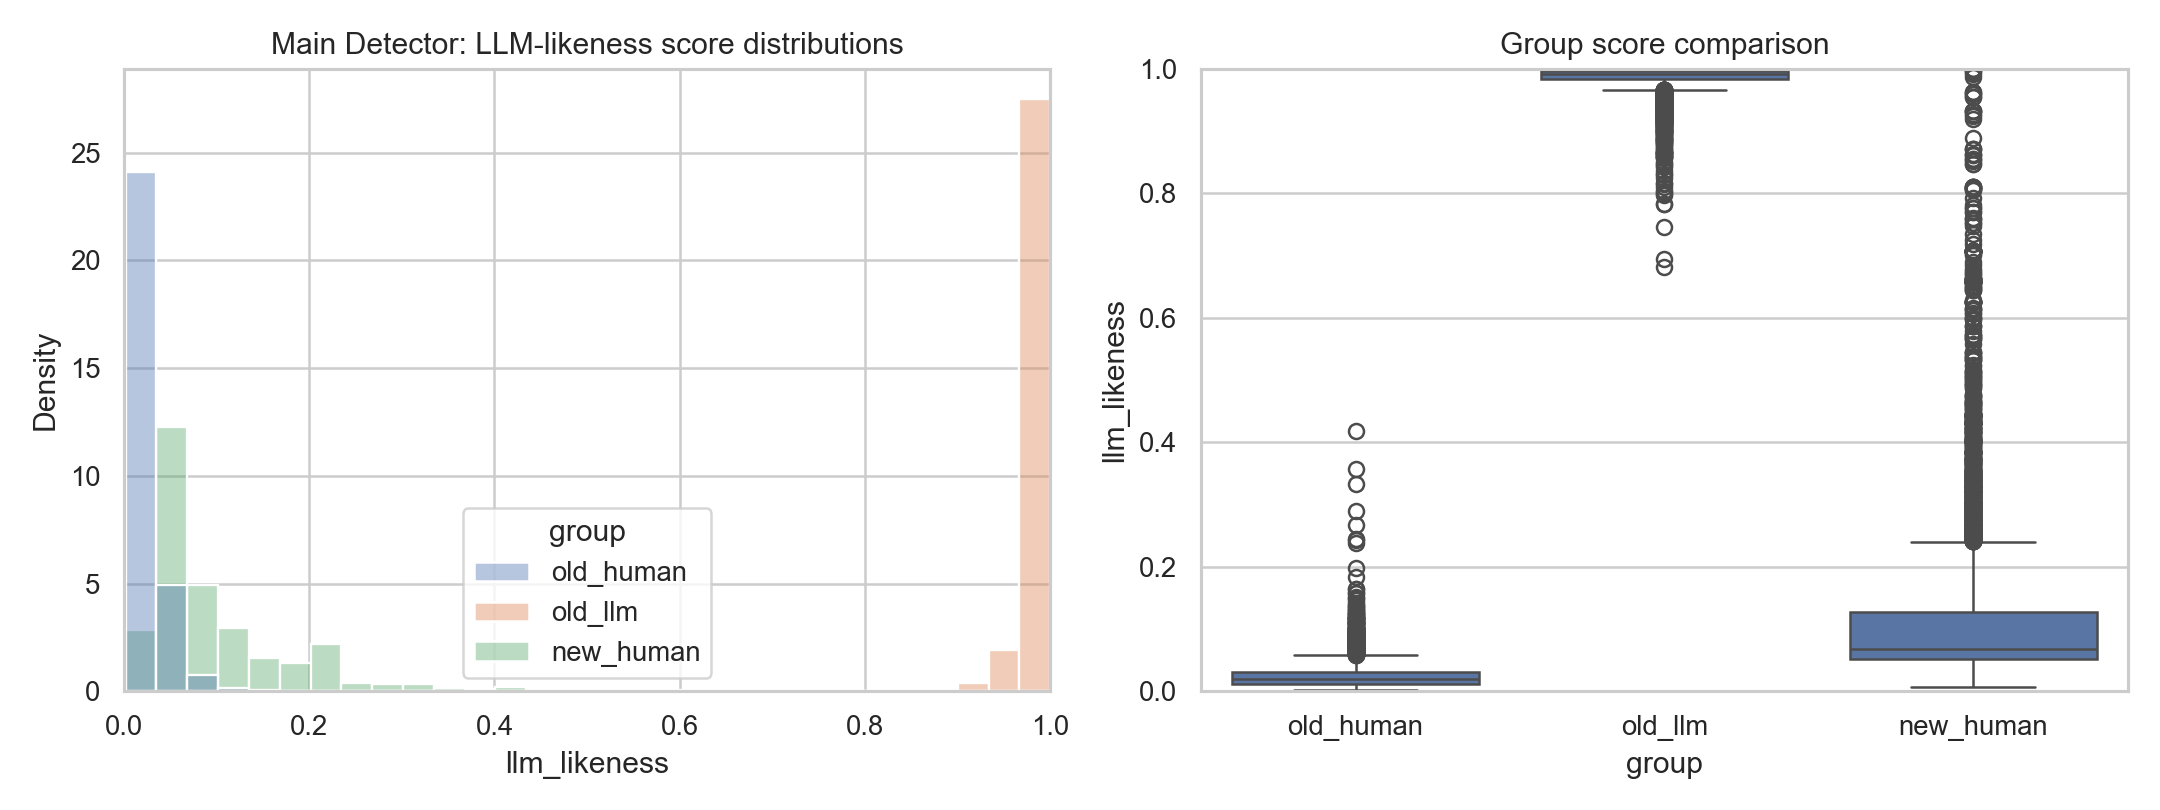

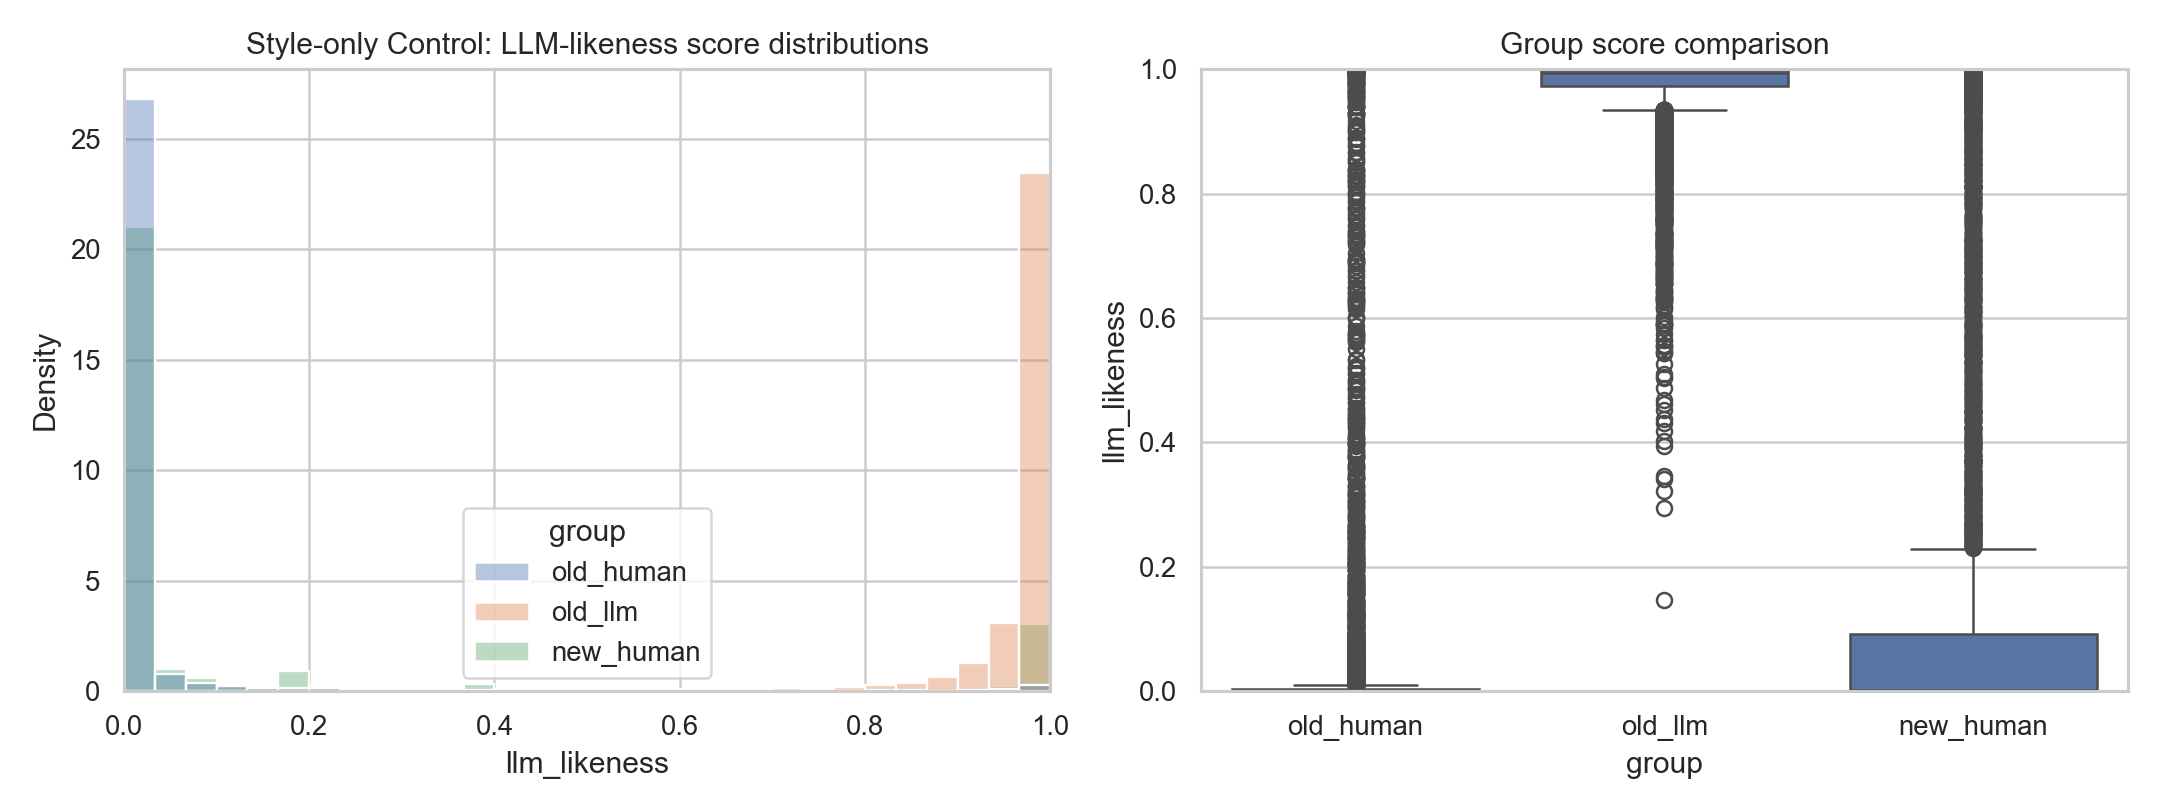

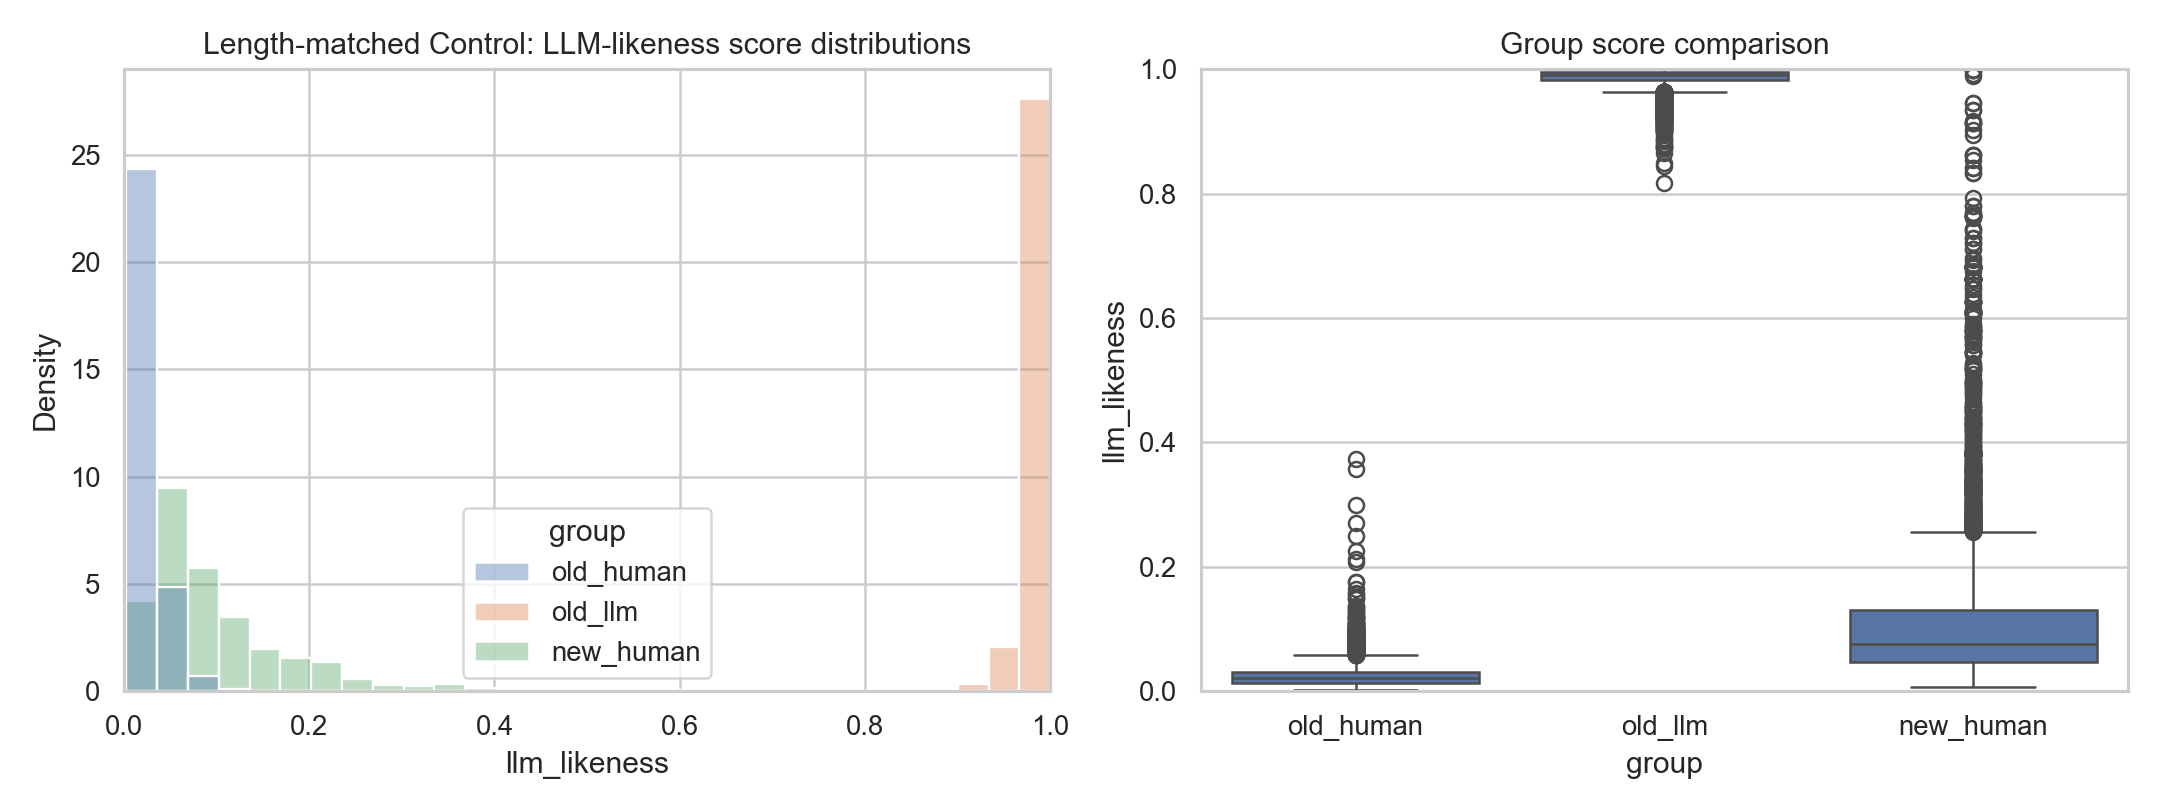

In [37]:
from IPython.display import Image, display

project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent
fig_paths = [
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_main.png',
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_style_only.png',
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_length_matched.png',
]

for fp in fig_paths:
    if fp.exists():
        display(Image(filename=str(fp)))
    else:
        print(f'Figure not found yet: {fp}')



### Preview Qualitative Audit Samples
This cell loads and previews high-scoring and low-scoring EBR examples selected for manual interpretation.

Step-by-step:
1. Resolve output file path.
2. Load qualitative audit CSV.
3. Display sample rows for human review.



In [38]:
project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent
audit_path = project_root / 'outputs' / 'qualitative_audit_samples.csv'

if audit_path.exists():
    audit = pd.read_csv(audit_path)
    audit.head(20)
else:
    print(f'Audit file not found yet: {audit_path}')

